# 00 · ¿Por qué MLOps? — Simulación de *data drift* y *concept drift*

Este notebook no entrena el "mejor modelo": entrena un modelo **bueno** y luego
muestra cómo **se degrada solo**, sin que nadie toque el código, cuando el mundo cambia.
Esa es la razón de ser de MLOps: un modelo en producción es un sistema vivo.

**Historia (inventada pero realista):** una empresa de entregas a domicilio en la
ciudad entrena en **enero** un modelo que predice si un pedido **llegará tarde**
usando dos variables:

| Variable | Qué es |
|---|---|
| `distancia_km` | distancia del restaurante al cliente |
| `trafico` | índice de tráfico de 0 (vacío) a 10 (embotellado) |

Luego simulamos dos cambios del mundo real:

1. **Data drift** (cambia la distribución de las X): la empresa se expande a zonas
   lejanas y empiezan a llegar pedidos de 10-16 km que el modelo casi nunca vio.
2. **Concept drift** (cambia la relación X → y): la municipalidad abre obras en la
   ciudad; con la misma distancia y el mismo tráfico, ahora los pedidos se atrasan más.

Y aprenderemos a **detectarlos**: el primero se ve mirando solo las X (sin etiquetas);
el segundo NO, solo aparece cuando llegan las etiquetas reales y medimos el desempeño.

## 1. Preparación
Fijamos `RANDOM_STATE = 42` para que todos obtengamos los mismos números
(reproducibilidad, uno de los pilares de MLOps).

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
plt.rcParams["figure.dpi"] = 100

## 2. El "mundo real" que genera los datos

La regla verdadera (que el modelo NO conoce, debe aprenderla) es:

$$\text{tarde} = 1 \iff \text{trafico} + 0.6\cdot\text{distancia} + \text{retraso\_extra} + \text{ruido} > 9$$

- `retraso_extra = 0` en enero. Si sube (obras), cambia **el concepto**.
- La distribución de `distancia_km` puede moverse (expansión): eso es **data drift**.

Escribirlo como función nos deja "fabricar" meses distintos controlando qué cambia.

In [2]:
def generar_mes(n, dist_media=5.0, dist_std=1.8, retraso_extra=0.0, seed=0):
    """Genera n pedidos de un mes. Devuelve X (DataFrame) e y (0/1)."""
    r = np.random.default_rng(seed)
    distancia = np.clip(r.normal(dist_media, dist_std, n), 0.5, None)
    trafico = r.uniform(0, 10, n)
    ruido = r.normal(0, 0.8, n)
    tarde = (trafico + 0.6 * distancia + retraso_extra + ruido > 9).astype(int)
    X = pd.DataFrame({"distancia_km": distancia, "trafico": trafico})
    return X, tarde

X_ene, y_ene = generar_mes(3000, seed=1)
print(X_ene.describe().round(2))
print(f"\nProporción de pedidos tarde en enero: {y_ene.mean():.3f}")

       distancia_km  trafico
count       3000.00  3000.00
mean           5.00     5.06
std            1.78     2.88
min            0.50     0.00
25%            3.78     2.61
50%            5.00     5.13
75%            6.22     7.56
max           11.75    10.00

Proporción de pedidos tarde en enero: 0.408


## 3. Entrenar en enero (el "notebook feliz")

Usamos un `RandomForestClassifier`, un modelo muy común en la industria.
Separamos enero en entrenamiento y prueba para tener la métrica "oficial" del notebook.

In [3]:
corte = 2400
modelo = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
modelo.fit(X_ene.iloc[:corte], y_ene[:corte])

acc_ene = accuracy_score(y_ene[corte:], modelo.predict(X_ene.iloc[corte:]))
print(f"Accuracy en enero (prueba): {acc_ene:.3f}")

Accuracy en enero (prueba): 0.912


**Interpretación:** con el mismo tipo de datos con que se entrenó, el modelo acierta
el **91.2 %** de los pedidos de prueba (y el 40.8 % de los pedidos de enero llegan tarde,
así que no es una clase rarísima). Si el proyecto terminara aquí ("¡funciona en mi
notebook!") lo declararíamos un éxito. MLOps existe porque **aquí empieza el problema**.

## 4. Data drift: la empresa se expande a zonas lejanas

En marzo la distancia media pasa de 5 km a 13 km. La **regla del mundo es la misma**;
lo que cambió es *qué tipo de pedidos llegan*.

¿Por qué debería fallar el modelo si la regla no cambió? Porque los árboles de
decisión **no extrapolan**: para cualquier distancia mayor que la más grande que
vieron en entrenamiento, predicen lo mismo que en ese borde. Nunca aprendieron
qué pasa a 14 km.

In [4]:
X_mar, y_mar = generar_mes(3000, dist_media=13.0, dist_std=2.0, seed=2)
acc_mar = accuracy_score(y_mar, modelo.predict(X_mar))
print(f"Distancia máxima vista en entrenamiento: {X_ene.distancia_km.iloc[:corte].max():.1f} km")
print(f"Distancia media en marzo:                {X_mar.distancia_km.mean():.1f} km")
print(f"Accuracy enero : {acc_ene:.3f}")
print(f"Accuracy marzo : {acc_mar:.3f}  (data drift)")
print(f"Pedidos tarde reales en marzo: {y_mar.mean():.3f} | predichos tarde: {modelo.predict(X_mar).mean():.3f}")

Distancia máxima vista en entrenamiento: 11.8 km
Distancia media en marzo:                12.9 km
Accuracy enero : 0.912
Accuracy marzo : 0.835  (data drift)
Pedidos tarde reales en marzo: 0.860 | predichos tarde: 0.707


**Interpretación:** el accuracy cae de 0.912 a **0.835** sin tocar una línea de código.
En zonas lejanas el 86.0 % de los pedidos llega tarde, pero el modelo solo marca como
tarde el 70.7 %: razona como si estuviera en el borde de lo que conoce (11.8 km) y
subestima el atraso de los pedidos más lejanos.

## 5. Concept drift: abren obras en la ciudad

Ahora las X tienen **exactamente la misma distribución que en enero** (misma ciudad,
mismas distancias, mismo tráfico), pero cada pedido tarda más: `retraso_extra = 2`.
Cambió $P(y \mid X)$, la relación que el modelo aprendió.

In [5]:
X_obras, y_obras = generar_mes(3000, retraso_extra=2.0, seed=3)
acc_obras = accuracy_score(y_obras, modelo.predict(X_obras))
print(f"Accuracy enero        : {acc_ene:.3f}")
print(f"Accuracy con obras    : {acc_obras:.3f}  (concept drift)")
print(f"Tarde real con obras  : {y_obras.mean():.3f} | predicho tarde: {modelo.predict(X_obras).mean():.3f}")

Accuracy enero        : 0.912
Accuracy con obras    : 0.816  (concept drift)


Tarde real con obras  : 0.601 | predicho tarde: 0.418


**Interpretación:** el accuracy cae a **0.816**. El modelo sigue prediciendo "tarde" para
el 41.8 % de los pedidos (lo mismo que en enero, porque las X se ven igual), pero ahora
en realidad se atrasa el 60.1 %. Nada en las entradas avisa del cambio.

## 6. ¿Cómo nos damos cuenta en producción? Monitorear X sin etiquetas

En producción **las etiquetas llegan tarde** (sabemos si el pedido llegó tarde
solo después de entregarlo; en un modelo de crédito, ¡meses después!). Lo primero que
se puede vigilar sin etiquetas es la distribución de las X.

Dos herramientas clásicas:

- **Prueba de Kolmogórov-Smirnov (KS):** compara dos distribuciones; un p-valor muy
  pequeño dice "estas muestras no vienen de la misma distribución".
- **PSI (Population Stability Index):** se divide la variable en cubetas (bins) con los
  datos de referencia y se compara qué porcentaje cae en cada una. Regla práctica de la
  industria: PSI < 0.1 estable, 0.1-0.25 vigilar, > 0.25 cambio importante.

In [6]:
def psi(referencia, actual, bins=10):
    """Population Stability Index usando cuantiles de la referencia."""
    cortes = np.quantile(referencia, np.linspace(0, 1, bins + 1))
    cortes[0], cortes[-1] = -np.inf, np.inf
    p_ref = np.histogram(referencia, cortes)[0] / len(referencia)
    p_act = np.histogram(actual, cortes)[0] / len(actual)
    p_ref, p_act = np.clip(p_ref, 1e-4, None), np.clip(p_act, 1e-4, None)
    return float(np.sum((p_act - p_ref) * np.log(p_act / p_ref)))

filas = []
for nombre, X_nuevo in [("marzo (expansión)", X_mar), ("obras", X_obras)]:
    for col in ["distancia_km", "trafico"]:
        ks = ks_2samp(X_ene[col], X_nuevo[col])
        filas.append({"escenario": nombre, "variable": col,
                      "KS_estadistico": round(ks.statistic, 3),
                      "p_valor": f"{ks.pvalue:.1e}",
                      "PSI": round(psi(X_ene[col], X_nuevo[col]), 3)})
monitoreo = pd.DataFrame(filas)
monitoreo

,escenario,variable,KS_estadistico,p_valor,PSI
0,marzo (expansión),distancia_km,0.965,0.0e+00,7.892
1,marzo (expansión),trafico,0.024,3.4e-01,0.007
2,obras,distancia_km,0.019,6.3e-01,0.003
3,obras,trafico,0.017,7.8e-01,0.002


**Interpretación:** en el escenario de expansión, `distancia_km` dispara las alarmas
(KS = 0.965, p-valor prácticamente cero, PSI = 7.9, treinta veces el umbral de 0.25): el data drift se
detecta **sin necesidad de etiquetas**. En el escenario de obras ninguna variable cambia
(PSI de 0.003 y 0.002, p-valores de 0.63 y 0.78): **el concept drift es invisible si solo miras las X**. Para cazarlo hay
que registrar las predicciones, esperar las etiquetas reales y medir el desempeño.

## 7. Gráfica: qué vio el monitoreo

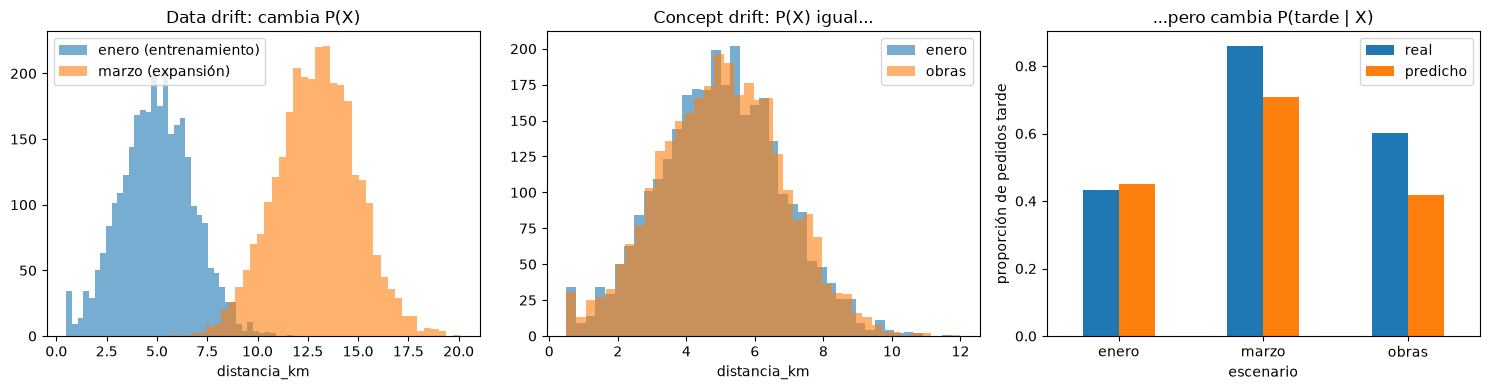

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(X_ene.distancia_km, bins=40, alpha=0.6, label="enero (entrenamiento)")
axes[0].hist(X_mar.distancia_km, bins=40, alpha=0.6, label="marzo (expansión)")
axes[0].set_title("Data drift: cambia P(X)")
axes[0].set_xlabel("distancia_km"); axes[0].legend()

axes[1].hist(X_ene.distancia_km, bins=40, alpha=0.6, label="enero")
axes[1].hist(X_obras.distancia_km, bins=40, alpha=0.6, label="obras")
axes[1].set_title("Concept drift: P(X) igual...")
axes[1].set_xlabel("distancia_km"); axes[1].legend()

tasa = pd.DataFrame({
    "escenario": ["enero", "marzo", "obras"],
    "real": [y_ene[corte:].mean(), y_mar.mean(), y_obras.mean()],
    "predicho": [modelo.predict(X_ene.iloc[corte:]).mean(), modelo.predict(X_mar).mean(),
                 modelo.predict(X_obras).mean()],
}).set_index("escenario")
tasa.plot.bar(ax=axes[2], rot=0)
axes[2].set_title("...pero cambia P(tarde | X)")
axes[2].set_ylabel("proporción de pedidos tarde")
plt.tight_layout()
plt.show()

## 8. Un año en producción: drift gradual y reentrenamiento

En la vida real el cambio no es de golpe. Simulamos 12 meses en los que las obras van
creciendo poco a poco (`retraso_extra` sube de 0 a 3). Comparamos dos estrategias:

- **Modelo congelado:** se entrena en enero y nunca se toca (MLOps nivel 0).
- **Reentrenamiento mensual:** cada mes se reentrena con los datos etiquetados del mes
  anterior (lo que automatiza un pipeline de MLOps nivel 1).

In [8]:
meses = ["ene", "feb", "mar", "abr", "may", "jun", "jul", "ago", "sep", "oct", "nov", "dic"]
retrasos = np.linspace(0, 3, 12)
datos_mes = [generar_mes(1500, retraso_extra=r_, seed=100 + i) for i, r_ in enumerate(retrasos)]

congelado = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
congelado.fit(*datos_mes[0])

acc_congelado, acc_reentrenado = [], []
for i in range(1, 12):
    X_i, y_i = datos_mes[i]
    acc_congelado.append(accuracy_score(y_i, congelado.predict(X_i)))
    reciente = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
    reciente.fit(*datos_mes[i - 1])          # solo datos YA etiquetados (mes anterior)
    acc_reentrenado.append(accuracy_score(y_i, reciente.predict(X_i)))

anio = pd.DataFrame({"mes": meses[1:], "retraso_extra": retrasos[1:].round(2),
                     "acc_congelado": np.round(acc_congelado, 3),
                     "acc_reentrenado": np.round(acc_reentrenado, 3)})
anio

,mes,retraso_extra,acc_congelado,acc_reentrenado
0,feb,0.27,0.931,0.931
1,mar,0.55,0.905,0.923
2,abr,0.82,0.905,0.919
3,may,1.09,0.886,0.922
4,jun,1.36,0.853,0.927
5,jul,1.64,0.833,0.927
6,ago,1.91,0.823,0.928
7,sep,2.18,0.799,0.923
8,oct,2.45,0.765,0.926
9,nov,2.73,0.742,0.927


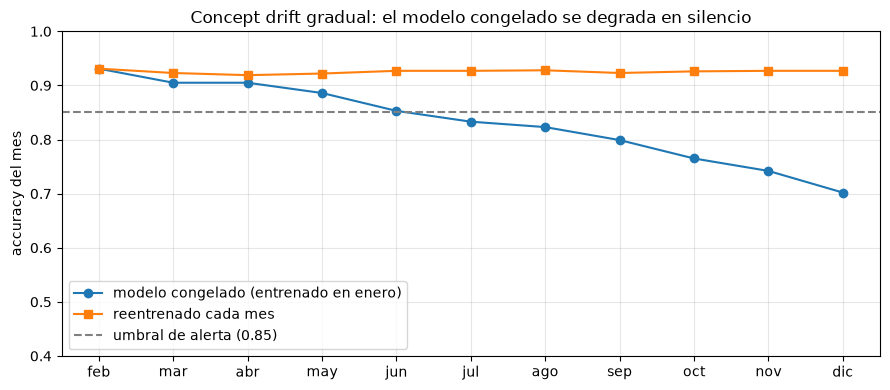

Primer mes con el modelo congelado bajo 0.85: jul
Accuracy promedio feb-dic  congelado: 0.831 | reentrenado: 0.925


In [9]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(anio.mes, anio.acc_congelado, "o-", label="modelo congelado (entrenado en enero)")
ax.plot(anio.mes, anio.acc_reentrenado, "s-", label="reentrenado cada mes")
ax.axhline(0.85, ls="--", c="gray", label="umbral de alerta (0.85)")
ax.set_ylabel("accuracy del mes"); ax.set_ylim(0.4, 1.0)
ax.set_title("Concept drift gradual: el modelo congelado se degrada en silencio")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

primer_alerta = anio.loc[anio.acc_congelado < 0.85, "mes"]
print("Primer mes con el modelo congelado bajo 0.85:",
      primer_alerta.iloc[0] if len(primer_alerta) else "ninguno")
print(f"Accuracy promedio feb-dic  congelado: {np.mean(acc_congelado):.3f}"
      f" | reentrenado: {np.mean(acc_reentrenado):.3f}")

**Interpretación:** el modelo congelado baja de 0.931 en febrero a **0.702** en diciembre
y cruza el umbral de alerta en **julio**, sin que nadie se dé cuenta (no hay error, no hay
excepción, la API responde normal). El modelo reentrenado cada mes se mantiene entre
0.919 y 0.931 (promedio 0.925 contra 0.831 del congelado), aunque siempre va "un mes
atrás". Eso es lo que automatiza MLOps: **monitorear → alertar → reentrenar → validar →
desplegar**, en ciclo.

## Resumen

| Concepto | Qué cambia | ¿Se ve sin etiquetas? | Cómo se detecta | Qué hacer |
|---|---|---|---|---|
| **Data drift** (covariate shift) | $P(X)$: llegan datos distintos | Sí | KS, PSI, comparar histogramas contra los de entrenamiento | Revisar si el modelo extrapola; reentrenar con los datos nuevos |
| **Concept drift** | $P(y \mid X)$: la regla del mundo | No | Medir accuracy/F1 cuando llegan las etiquetas reales | Reentrenar con datos recientes; a veces rediseñar variables |

- Un modelo que funciona en el notebook **no garantiza nada** en producción: los datos
  del futuro no son los del pasado.
- El monitoreo necesita **dos capas**: estadísticas de las entradas (rápidas, sin
  etiquetas) y métricas de desempeño (lentas, con etiquetas).
- Reentrenar automáticamente con datos recientes recupera el desempeño: ese ciclo
  (monitorear → reentrenar → validar → desplegar) es el corazón de MLOps.